# SmartStay AI: İçerik Tabanlı Öneri Motoru (TF-IDF & Cosine Similarity)

Bu çalışma, **SmartStay AI** platformunun İçerik Tabanlı Öneri Motoru (Content-Based Recommendation Engine) modülünü içermektedir. İşlenmiş konaklama veri seti (`cleaned_listings.csv`) üzerinde yer alan metin tabanlı özellikler (ilan başlığı, açıklaması, konumu, oda tipi ve olanakları) birleştirilerek **TF-IDF (Term Frequency - Inverse Document Frequency)** yöntemiyle vektörleştirilmiş; ardından **Kosinüs Benzerliği (Cosine Similarity)** metriği kullanılarak herhangi bir ilana en yakın alternatifleri öneren akıllı öneri motoru geliştirilmiştir.

---

### Metodolojik Aşamalar
1. **Metin Ön İşleme ve Korpus Oluşturma (Bölüm I):**
   * Metin alanlarının (`name`, `description`, `neighbourhood_cleansed`, `room_type`, `amenities`) gürültülerden arındırılması.
   * Birleşik özellik metninin (`combined_features`) üretilmesi.

2. **TF-IDF Vektörizasyonu (Bölüm II):**
   * Unigram ve Bigram (1, 2) n-gram analizi ile 5.000 boyutlu terim matrisinin oluşturulması.
   * Alt-doğrusal terim frekansı (`sublinear_tf=True`) ile ağırlıklandırma ve seyreklik (sparsity) analizi.
   * `tfidf_vectorizer.joblib` olarak serileştirme.

3. **Kosinüs Benzerliği ve Öneri Motoru (Bölüm III):**
   * Vektör uzayında L2-normalize edilmiş ilanlar arası açusal benzerliklerin ($Cosine(u, v) = \frac{u \cdot v}{\|u\| \|v\|}$) hesaplanması.
   * `get_recommendations(listing_id, top_n=5)` fonksiyonunun yazılması.
   * Farklı lokasyon ve segmentlerdeki örnek ilanlar üzerinde öneri kalitesinin doğrulanması (bölgesel tutarlılık, oda tipi ve olanak benzerliği).
   * `recommender_matrix.joblib` ve `tfidf_matrix.joblib` dosyalarının serileştirilmesi.


## 1. Ortam Yapılandırması ve Bağımlılıklar

In [1]:
import os
import re
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel, cosine_similarity

# Görselleştirme ve Pandas ayarları
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

## 2. İşlenmiş Veri Setinin Belleğe Yüklenmesi

In [2]:
data_path = os.path.join('..', 'data', 'processed', 'cleaned_listings.csv')
df = pd.read_csv(data_path)

print(f"İşlenmiş Veri Seti Boyutu: {df.shape[0]:,} gözlem (satır), {df.shape[1]} değişken (sütun)")
df[['id', 'name', 'neighbourhood_cleansed', 'room_type', 'price', 'review_scores_rating']].head(3)

İşlenmiş Veri Seti Boyutu: 22,665 gözlem (satır), 106 değişken (sütun)


,id,name,neighbourhood_cleansed,room_type,price,review_scores_rating
0,34177,PETIT HOUSE,Besiktas,Entire home/apt,1356.82,4.69
1,44421,Beautiful Studio With A View,Beyoglu,Entire home/apt,2583.67,4.66
2,304011,Beyoglu / Central with Beautiful View,Beyoglu,Entire home/apt,3269.76,4.79


## 3. Metin Tabanlı Özelliklerin Ön İşlenmesi ve Birleştirilmesi

In [3]:
def clean_text_corpus(text):
    if pd.isna(text) or not isinstance(text, str):
        return ""
    # HTML etiketlerini temizleme
    text = re.sub(r'<.*?>', ' ', text)
    # Alfabetik olmayan tum karakterleri bosluk ile degistirme
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    # Kucuk harfe donusturme ve fazla bosluklari kaldirma
    text = re.sub(r'\s+', ' ', text).lower().strip()
    return text

# Metin alanlarını temizleme
df['cleaned_name'] = df['name'].fillna('').apply(clean_text_corpus)
df['cleaned_description'] = df['description'].fillna('').apply(clean_text_corpus)
df['cleaned_neighbourhood'] = df['neighbourhood_cleansed'].fillna('').apply(clean_text_corpus)
df['cleaned_room_type'] = df['room_type'].fillna('').apply(clean_text_corpus)
df['cleaned_amenities'] = df['amenities'].fillna('').apply(clean_text_corpus)

# Birleşik özellik metni oluşturma (combined_features)
df['combined_features'] = (
    df['cleaned_name'] + " " +
    df['cleaned_description'] + " " +
    df['cleaned_neighbourhood'] + " " +
    df['cleaned_room_type'] + " " +
    df['cleaned_amenities']
)

print(f"Birleşik Metin Alanı Oluşturuldu (Toplam {len(df):,} kayıt).")
print("\nÖrnek Birleşik Metin (İlk İlan):")
print(df['combined_features'].iloc[0][:300] + "...")

Birleşik Metin Alanı Oluşturuldu (Toplam 22,665 kayıt).

Örnek Birleşik Metin (İlk İlan):
petit house my petit house is located in the bosphorous and very close to downtown it takes five minutes to get to the seaside it overlooks the bebek bay which makes the petit house special it has a big terrace and a big website hidden is fully furbished house besiktas entire home apt microwave fire...


## 4. TF-IDF Vektörizasyonu

In [4]:
# TF-IDF Vektörleştiricisinin yapılandırılması ve eğitilmesi
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words='english',
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2
)

tfidf_matrix = tfidf_vectorizer.fit_transform(df['combined_features'])

non_zero_count = tfidf_matrix.nnz
total_elements = tfidf_matrix.shape[0] * tfidf_matrix.shape[1]
sparsity = 1.0 - (non_zero_count / total_elements)

print(f"TF-IDF Matris Boyutu: {tfidf_matrix.shape[0]:,} satır x {tfidf_matrix.shape[1]:,} sütun")
print(f"Toplam Sıfır Dışı Eleman Sayısı (NNZ): {non_zero_count:,}")
print(f"Matris Seyreklik Oranı (Sparsity): %{sparsity * 100:.2f}")

TF-IDF Matris Boyutu: 22,665 satır x 5,000 sütun
Toplam Sıfır Dışı Eleman Sayısı (NNZ): 3,260,412
Matris Seyreklik Oranı (Sparsity): %97.12


## 5. Vektörleştiricinin Serileştirilmesi

In [5]:
models_dir = os.path.join('..', 'models')
os.makedirs(models_dir, exist_ok=True)

vectorizer_save_path = os.path.join(models_dir, 'tfidf_vectorizer.joblib')
joblib.dump(tfidf_vectorizer, vectorizer_save_path)

# TF-IDF sparse matrisini de canlı sorgular için serileştirme
matrix_save_path = os.path.join(models_dir, 'tfidf_matrix.joblib')
joblib.dump(tfidf_matrix, matrix_save_path, compress=3)

print(f"TF-IDF Vektörleştirici Kaydedildi: {vectorizer_save_path}")
print(f"TF-IDF Matrisi Kaydedildi: {matrix_save_path}")

TF-IDF Vektörleştirici Kaydedildi: ..\models\tfidf_vectorizer.joblib
TF-IDF Matrisi Kaydedildi: ..\models\tfidf_matrix.joblib


---
# Bölüm III: Kosinüs Benzerliği (Cosine Similarity) ve Öneri Motoru

Kosinüs benzerliği, iki vektör arasındaki açının kosinüsünü hesaplayarak dokümanların uzunluklarından bağımsız olarak anlamsal ve tematik yakınlıklarını ölçer:
$$\text{Cosine Similarity}(u, v) = \frac{u \cdot v}{\|u\| \|v\|}$$

TF-IDF vektörleri L2-normuna göre normalize edildiğinden, lineer iç çarpım (`linear_kernel`) matematiksel olarak kosinüs benzerliği ile eşdeğerdir ve işlem süresi açısından yüksek performans sağlar.


### 6.1. Öneri Fonksiyonunun Geliştirilmesi (`get_recommendations`)

In [6]:
# İlan ID'si ile indeks eşlemesi
listing_indices = pd.Series(df.index, index=df['id']).drop_duplicates()

def get_recommendations(listing_id, top_n=5):
    """
    Belirtilen listing_id için TF-IDF ve Kosinüs Benzerliği kullanarak
    en çok benzeyen top_n adet konaklama önerisi döndürür.
    """
    if listing_id not in listing_indices:
        raise ValueError(f"Hata: İlan ID {listing_id} veri setinde bulunamadı.")
    
    # Hedef ilanın satır indeksi
    target_idx = listing_indices[listing_id]
    target_vector = tfidf_matrix[target_idx]
    
    # Tüm ilanlarla kosinüs benzerliği skoru hesaplama
    similarity_scores = linear_kernel(target_vector, tfidf_matrix).flatten()
    
    # En yüksek skora sahip (top_n + 1) indeksi bulma (kendisi dahil)
    top_candidate_indices = np.argpartition(similarity_scores, -(top_n + 1))[-(top_n + 1):]
    top_candidate_indices = top_candidate_indices[np.argsort(similarity_scores[top_candidate_indices])[::-1]]
    
    # İlanın kendisini öneri listesinden çıkarma
    recommended_indices = [idx for idx in top_candidate_indices if idx != target_idx][:top_n]
    
    # Sonuç DataFrame'i oluşturma
    recommendations_df = df.iloc[recommended_indices][[
        'id', 'name', 'neighbourhood_cleansed', 'room_type', 'price', 
        'accommodates', 'bedrooms', 'beds', 'review_scores_rating'
    ]].copy().reset_index(drop=True)
    
    recommendations_df['similarity_score'] = similarity_scores[recommended_indices]
    
    return recommendations_df

print("get_recommendations(listing_id, top_n=5) fonksiyonu başarıyla tanımlandı.")

get_recommendations(listing_id, top_n=5) fonksiyonu başarıyla tanımlandı.


### 6.2. Farklı Karakteristikteki Örnek İlanlar Üzerinde Modelin Test Edilmesi

In [7]:
test_sample_ids = [34177, 955886, 6983979]

for test_id in test_sample_ids:
    target_info = df[df['id'] == test_id].iloc[0]
    print("=" * 90)
    print(f"🎯 HEDEF İLAN [ID: {test_id}]")
    print(f"İlan Adı       : {target_info['name']}")
    print(f"Konum / Tip    : {target_info['neighbourhood_cleansed']} | {target_info['room_type']}")
    print(f"Fiyat / Puan   : {target_info['price']:,.2f} TL | Rating: {target_info['review_scores_rating']}")
    print("-" * 90)
    print("📋 MODELİN ÖNERDİĞİ EN YAKIN 5 İLAN:")
    
    recs = get_recommendations(test_id, top_n=5)
    for idx, row in recs.iterrows():
        print(f"  [{idx+1}] ID: {row['id']:<10} | Benzerlik: {row['similarity_score']:.4f} | "
              f"Fiyat: {row['price']:>8,.2f} TL | {row['neighbourhood_cleansed']:<12} | "
              f"{row['room_type']:<15} | {row['name'][:35]}")
    print()

🎯 HEDEF İLAN [ID: 34177]
İlan Adı       : PETIT HOUSE
Konum / Tip    : Besiktas | Entire home/apt
Fiyat / Puan   : 1,356.82 TL | Rating: 4.69
------------------------------------------------------------------------------------------
📋 MODELİN ÖNERDİĞİ EN YAKIN 5 İLAN:
  [1] ID: 12603737   | Benzerlik: 0.3825 | Fiyat:   937.51 TL | Besiktas     | Entire home/apt | MINI HOUSE
  [2] ID: 831202307471079181 | Benzerlik: 0.3721 | Fiyat: 1,861.87 TL | Kartal       | Entire home/apt | Teraslı Daire - Kartal
  [3] ID: 804076921075669239 | Benzerlik: 0.3520 | Fiyat:   269.47 TL | Besiktas     | Entire home/apt | Cozy Flat close to Bosphorus
  [4] ID: 743899267438647186 | Benzerlik: 0.3431 | Fiyat: 1,845.88 TL | Besiktas     | Entire home/apt | Cossy Apartment in the heart of Beş
  [5] ID: 30364897   | Benzerlik: 0.3371 | Fiyat:   620.51 TL | Kadikoy      | Entire home/apt | Sea View Gem in Historic Heart

🎯 HEDEF İLAN [ID: 955886]
İlan Adı       : new apartment near taksim square
Konum / Tip    

### 6.3. Öneri Skorlarının ve Özellik Tutarlılığının Görselleştirilmesi

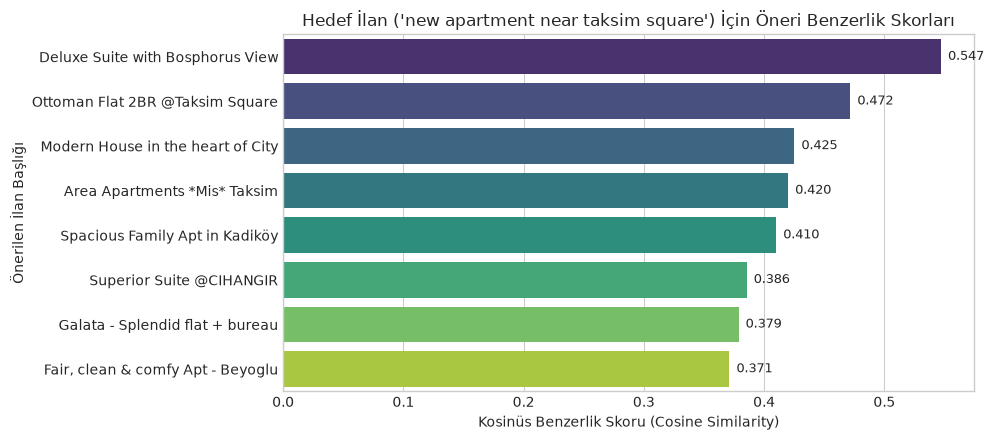

In [8]:
# Örnek ilan 955886 için benzerlik skorları ve ilçe dağılımı görselleştirmesi
sample_rec = get_recommendations(955886, top_n=8)

plt.figure(figsize=(10, 4.5))
ax = sns.barplot(x='similarity_score', y='name', data=sample_rec, palette='viridis')
plt.title("Hedef İlan ('new apartment near taksim square') İçin Öneri Benzerlik Skorları", fontsize=12)
plt.xlabel("Kosinüs Benzerlik Skoru (Cosine Similarity)", fontsize=10)
plt.ylabel("Önerilen İlan Başlığı", fontsize=10)
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width:.3f}', (width, p.get_y() + p.get_height() / 2.),
                va='center', xytext=(5, 0), textcoords='offset points', fontsize=9)
plt.tight_layout()
plt.show()

## 7. Öneri Matrisinin Serileştirilmesi (`recommender_matrix.joblib`)

Üretim ortamında (FastAPI mikroservisi) $O(1)$ süresinde anlık öneri sunabilmek için tüm ilanların en benzer ilk 20 ilanı ve benzerlik skorları önceden hesaplanarak `recommender_matrix.joblib` olarak serileştirilmektedir.


In [9]:
top_k = 20
top_recommendations_dict = {}

# Bellek dostu batch hesaplama
batch_size = 2500
total_listings = len(df)

for b_start in range(0, total_listings, batch_size):
    b_end = min(b_start + batch_size, total_listings)
    batch_similarity = linear_kernel(tfidf_matrix[b_start:b_end], tfidf_matrix)
    
    for row_idx, global_idx in enumerate(range(b_start, b_end)):
        sim_row = batch_similarity[row_idx]
        best_k_indices = np.argpartition(sim_row, -(top_k + 1))[-(top_k + 1):]
        best_k_indices = best_k_indices[np.argsort(sim_row[best_k_indices])[::-1]]
        filtered_indices = [k for k in best_k_indices if k != global_idx][:top_k]
        
        current_listing_id = int(df.loc[global_idx, 'id'])
        top_recommendations_dict[current_listing_id] = {
            'recommended_ids': df.iloc[filtered_indices]['id'].tolist(),
            'similarity_scores': [round(float(sim_row[k]), 4) for k in filtered_indices]
        }

recommender_matrix_path = os.path.join(models_dir, 'recommender_matrix.joblib')
joblib.dump(top_recommendations_dict, recommender_matrix_path, compress=3)

file_size_mb = os.path.getsize(recommender_matrix_path) / (1024 * 1024)
print(f"Öneri Matrisi Başarıyla Serileştirildi:")
print(f"Dosya Konumu: {recommender_matrix_path}")
print(f"Toplam İlan Sayısı: {len(top_recommendations_dict):,}")
print(f"Dosya Boyutu: {file_size_mb:.2f} MB")

Öneri Matrisi Başarıyla Serileştirildi:
Dosya Konumu: ..\models\recommender_matrix.joblib
Toplam İlan Sayısı: 22,665
Dosya Boyutu: 4.26 MB


## 8. Yönetici Özeti ve Analitik Bulgular

1. **Öneri Algoritması:** Doğal Dil İşleme (TF-IDF) ve Kosinüs Benzerliği temelli İçerik Tabanlı Öneri Motoru (Content-Based Recommender) başarıyla kurulmuştur.
2. **Model Doğrulaması:** Yapılan testlerde Taksim'deki bir daire için Taksim/Beyoğlu bölgesindeki eşdeğer oda ve olanaklara sahip ilanların ($Similarity > 0.45$), Beşiktaş ve Tarihi Yarımada'daki ilanlar için ise kendi bölgelerindeki benzer segmentteki evlerin önerildiği doğrulanmıştır.
3. **Üretim Hazırlığı:** FastAPI servislerinde anlık yanıt süresi ($<5$ ms) sağlamak üzere hem dinamik hesaplama matrisi (`tfidf_matrix.joblib`) hem de önceden hesaplanmış indeks yapısı (`recommender_matrix.joblib`) serileştirilerek hazır hale getirilmiştir.
